# Mean absolute error and Pearson correlation

A reviewer asked for an error metric besides the RMSE and for the Pearson correlation between measurement and prediction. This notebook computes both for every model of the project on the hold-out, from the saved predictions, together with the bias and the R2.

The correlation is given twice. **Pooled**, over all links, it is dominated by the differences between the links, which span 60 dB, so even a model that predicts one constant per link scores close to 1. **Within link**, after removing the mean of each link from the measurement and from the prediction, it measures whether the model follows the variation of a link in time, which is what the margin depends on. A model that predicts a constant per link has no within-link correlation by construction.

All scores are on the hold-out packets that every model predicts, with 95 % intervals from resampling days. The references that need no model are the training mean of each link and the previous-hour mean.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from margin_tools import day_codes, boot_stat

In [2]:
# The hold-out packets and the saved predictions of every model, aligned on (link, time)
d = pd.read_csv("Data_Files/history_test.csv", usecols=["device_id", "t", "PL", "a", "devmean"])
d["t"] = pd.to_datetime(d["t"], utc=True)
position = pd.Series(np.arange(len(d)), index=pd.MultiIndex.from_arrays([d["device_id"], d["t"]]))
PL, link = d["PL"].to_numpy(), d["device_id"].to_numpy()

def saved(name):
    r = pd.read_csv(f"Residuals/residuals_{name}_test.csv", usecols=["time", "device_id", "PL_pred"])
    i = position.reindex(pd.MultiIndex.from_arrays([r["device_id"], pd.to_datetime(r["time"], utc=True)])).to_numpy()
    p = np.full(len(d), np.nan)
    found = ~np.isnan(i)
    p[i[found].astype(int)] = r["PL_pred"].to_numpy()[found]
    return p

pred = {"per-link mean": d["devmean"].to_numpy(), "previous hour mean": d["a"].to_numpy()}
for name, file in [("free-space loss", "PLM_FSPL"), ("fixed-point LDPLM", "PLM_FIXED_POINT_LDPLM"), ("Motley-Keenan", "PLM_MOTLEY_KEENAN"), ("ITU-R P.1238", "PLM_ITU_R_P1238"),
                   ("COST 231 multi-wall", "PLM_COST231_MWM"), ("linear regression", "MLR"), ("random forest", "RF"), ("XGBoost", "XGB"), ("LightGBM", "LGBM"), ("kNN", "KNN"), ("ANN", "ANN")]:
    pred[f"{name}, static"] = saved(file)
for fam, label in [("Linear", "linear regression"), ("RF", "random forest"), ("XGB", "XGBoost"), ("LGBM", "LightGBM"), ("KNN", "kNN"), ("ANN", "ANN"), ("GRU", "GRU")]:
    for rung in ("H1", "H4", "H6", "H7"):
        pred[f"{label}, rung {rung}"] = saved(f"{fam}_{rung}")
common = np.all([np.isfinite(p) for p in pred.values()], axis=0)
te = np.flatnonzero(common)
dd = pd.factorize(day_codes(d["t"])[te])[0]
print(f"{len(pred)} models; hold-out packets that every model predicts: {len(te):,} of {len(d):,}")

41 models; hold-out packets that every model predicts: 531,983 of 532,055


In [3]:
# Scores with 95 % intervals from resampling days
def correlation(T):                      # T: n, sum x, sum y, sum xx, sum yy, sum xy
    return (T[:, 0] * T[:, 5] - T[:, 1] * T[:, 2]) / np.sqrt((T[:, 0] * T[:, 3] - T[:, 1] ** 2) * (T[:, 0] * T[:, 4] - T[:, 2] ** 2))

ones = np.ones(len(te))
mean_by_link = lambda x: pd.Series(x).groupby(link[te]).transform("mean").to_numpy()
x = PL[te]
x_c = x - mean_by_link(x)
rows = []
for name, p in pred.items():
    y_ = p[te]
    e = y_ - x
    y_c = y_ - mean_by_link(y_)
    mae = boot_stat(dd, np.column_stack([np.abs(e), ones]), lambda T: T[:, 0] / T[:, 1])
    rmse = boot_stat(dd, np.column_stack([e ** 2, ones]), lambda T: np.sqrt(T[:, 0] / T[:, 1]))
    pooled = boot_stat(dd, np.column_stack([ones, x, y_, x * x, y_ * y_, x * y_]), correlation)
    constant = np.allclose(y_c, 0)                                  # one value per link: no variation to correlate
    within = (np.nan, np.nan, np.nan) if constant else boot_stat(dd, np.column_stack([ones, x_c, y_c, x_c * x_c, y_c * y_c, x_c * y_c]), correlation)
    rows.append({"model": name, "MAE": mae[0], "MAE_lo": mae[1], "MAE_hi": mae[2], "RMSE": rmse[0], "bias": e.mean(), "R2": 1 - (e ** 2).sum() / ((x - x.mean()) ** 2).sum(),
                 "r_pooled": pooled[0], "r_pooled_lo": pooled[1], "r_pooled_hi": pooled[2], "r_within": within[0], "r_within_lo": within[1], "r_within_hi": within[2]})
metrics = pd.DataFrame(rows).set_index("model")
metrics.to_csv("CV_Results/error_metrics.csv")
pd.set_option("display.width", 220)
display(metrics[["MAE", "RMSE", "bias", "R2", "r_pooled", "r_within"]].round(3))

,MAE,RMSE,bias,R2,r_pooled,r_within
model,,,,,,
per-link mean,4.015,5.035,1.475,0.903,0.957,NaN
previous hour mean,2.046,2.712,0.000,0.972,0.986,0.780
"free-space loss, static",28.709,30.905,-28.709,-2.641,0.933,-0.105
"fixed-point LDPLM, static",5.962,7.177,2.349,0.804,0.933,-0.105
"Motley-Keenan, static",7.843,9.716,-2.390,0.640,0.913,-0.105
"ITU-R P.1238, static",5.917,7.128,2.330,0.806,0.933,-0.105
"COST 231 multi-wall, static",5.092,6.382,1.488,0.845,0.924,-0.105
"linear regression, static",4.154,5.252,1.456,0.895,0.951,-0.100
"random forest, static",3.924,4.931,1.297,0.907,0.957,-0.053


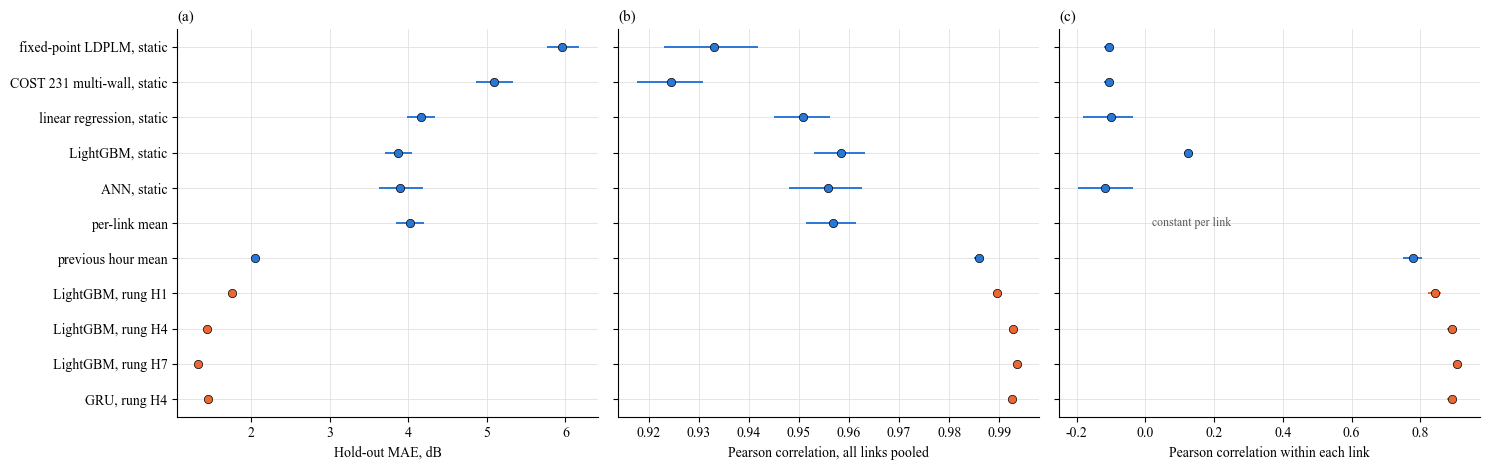

In [4]:
# Figure: MAE, pooled correlation and within-link correlation for the main models
plt.rcParams.update({"font.family": "serif", "font.serif": ["Times New Roman", "DejaVu Serif"], "font.size": 10})
shown = ["fixed-point LDPLM, static", "COST 231 multi-wall, static", "linear regression, static", "LightGBM, static", "ANN, static", "per-link mean", "previous hour mean",
         "LightGBM, rung H1", "LightGBM, rung H4", "LightGBM, rung H7", "GRU, rung H4"]      # the free-space loss, at 28.7 dB, would stretch the first panel
m = metrics.loc[shown]
pos = np.arange(len(shown))[::-1]
learned = ["#eb6834" if "rung" in n else "#2a78d6" for n in shown]
fig, ax = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True)
for a_, (col, lo, hi, label) in zip(ax, [("MAE", "MAE_lo", "MAE_hi", "Hold-out MAE, dB"), ("r_pooled", "r_pooled_lo", "r_pooled_hi", "Pearson correlation, all links pooled"),
                                          ("r_within", "r_within_lo", "r_within_hi", "Pearson correlation within each link")]):
    ok = m[col].notna().to_numpy()
    for i in np.flatnonzero(ok):
        a_.errorbar(m[col].iloc[i], pos[i], xerr=[[m[col].iloc[i] - m[lo].iloc[i]], [m[hi].iloc[i] - m[col].iloc[i]]], fmt="o", color=learned[i], ms=6, mec="black", mew=0.5, lw=1.4)
    a_.set_xlabel(label)
    a_.grid(color="0.88", lw=0.6)
    a_.set_axisbelow(True)
    for sp in ("top", "right"):
        a_.spines[sp].set_visible(False)
ax[0].set_yticks(pos, shown)
ax[2].text(0.02, pos[shown.index("per-link mean")], "constant per link", va="center", fontsize=8.5, color="0.35")
for a_, tag in zip(ax, "abc"):
    a_.set_title(f"({tag})", loc="left", fontsize=11)
fig.tight_layout()
fig.savefig("Figures/error_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

**Reading of the results.**

* **MAE.** The static machine-learning models have a hold-out MAE of 3.75 to 4.15 dB, XGBoost the lowest at 3.75 dB with an interval from 3.56 to 3.96, and the per-link mean 4.02 dB, inside that interval. COST 231 reaches 5.09 dB, the fixed-point LDPLM and the ITU-R model 5.9 dB, Motley-Keenan 7.8 dB and the free-space loss 28.7 dB. With the link's history the MAE falls to 1.75 to 1.91 dB at rung H1, 1.43 to 1.80 dB at rung H4 and 1.32 dB for the LightGBM at rung H7. The previous-hour mean alone gives 2.05 dB.
* **The pooled correlation tells almost nothing.** It is 0.957 for one constant per link, between 0.951 and 0.960 for every static machine-learning model, and 0.924 for COST 231. The links differ by 60 dB, so any model that knows the link scores above 0.95. The models with history reach 0.988 to 0.994.
* **The correlation within each link is the informative one.** For the static models it lies between -0.12 and +0.13: no static model follows the variation of a link in time. The LightGBM reaches +0.13, with an interval from 0.11 to 0.14, XGBoost 0.00, the ANN -0.12. The empirical models and COST 231 stand at -0.11, because only the channel frequency varies within a link. The previous-hour mean reaches 0.78, with an interval from 0.75 to 0.81, and the history models 0.81 to 0.91, the LightGBM 0.89 at rung H4 and 0.91 at rung H7.
* **Bias.** On the summer hold-out the static models are off by -0.2 to +1.5 dB, the LightGBM by +1.45 dB. The history models are off by at most 0.17 dB, because they are anchored to the recent level of the link.
* **R2** shows the same as the pooled correlation: 0.90 to 0.91 for the static machine-learning models and 0.90 for the per-link mean, 0.98 to 0.99 with history.